# Data Loading & Preprocessing

[Prev](01_setup.ipynb) | [Index](00_index.ipynb) | [Next](03_model.ipynb)

---


In [9]:
from pathlib import Path
DATADIR = Path("data/Condata")  # update to your local dataset path
CATEGORIES = ["0", "1", "2", "3", "4", "5","6", "7", "8", "9","10", "11", "12", "13", "14", "15", "16", "17", "18", "19", "20", "21", "22", "23"]
dataset = []
img_size = (64, 64)
max_images_per_class = 200  # Total required images (5000 for train, 1000 for test, 1000 for validation)

# Step 1: Load images
for category in tqdm(CATEGORIES):  
    path = os.path.join(DATADIR, category)  
    class_num = CATEGORIES.index(category)
    image_count = 0
    for img in os.listdir(path):
        if image_count >= max_images_per_class:
            break
        try:
            img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_COLOR)
            image_rgb = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)
            new_array = cv2.resize(image_rgb, img_size)
            dataset.append([new_array, class_num])
            image_count += 1
        except Exception as e:
            pass

# Step 2: Separate features (X) and labels (Y)
X = [] # features
Y = [] # labels

for features, label in dataset:
    X.append(features)
    Y.append(label)


100%|██████████| 24/24 [00:24<00:00,  1.04s/it]


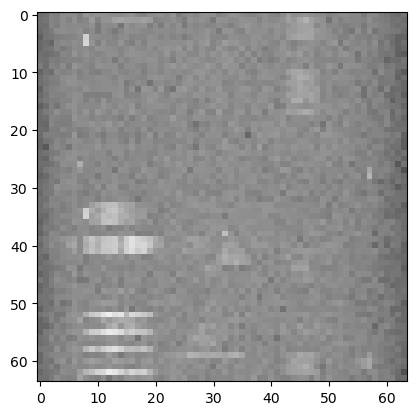

In [10]:
import matplotlib.pyplot as plt
 
plt.imshow(X[1])

In [11]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

X_train = np.array(X_train).reshape(-1, img_size[0], img_size[1], 3)
Y_train = np.array(Y_train).reshape(-1,)
#X_train = ( X_train)/255

X_test = np.array(X_test).reshape(-1,  img_size[0], img_size[1], 3)
Y_test = np.array(Y_test).reshape(-1,)
#X_test = (X_test)/255